# 第12节：数据隐私攻击与保护策略

覆盖主题：
- 成员推理（Membership Inference）风险：为什么过拟合会带来“成员可分辨性”
- 属性重建（Attribute/Feature Inference）风险：表征泄露与侧信息结合
- 差分隐私（DP）原理：ε/δ、Laplace/Gaussian、组合定理、隐私预算
- 联邦差分机制：FedAvg + 噪声/裁剪（工程化视角）
- 加密计算简介：MPC/HE/TEE 的适用边界与成本


## 0. 路径与环境（与前几节一致）

notebooks 与 data 同级，工作目录通常在 `project_root/notebooks`。
统一使用：
```python
PROJECT_ROOT = Path.cwd().resolve().parent
```

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

PROJECT_ROOT = Path.cwd().resolve().parent
DATA_DIR = PROJECT_ROOT / 'data'
MODELS_DIR = PROJECT_ROOT / 'models'

print('CWD:', Path.cwd())
print('PROJECT_ROOT:', PROJECT_ROOT)
print('DATA_DIR exists:', DATA_DIR.exists(), '|', DATA_DIR)
print('MODELS_DIR exists:', MODELS_DIR.exists(), '|', MODELS_DIR)

device = torch.device('cpu')
print('torch:', torch.__version__, 'device:', device)


CWD: C:\Users\wingl\PycharmProjects\adversarialmeow\notebooks
PROJECT_ROOT: C:\Users\wingl\PycharmProjects\adversarialmeow
DATA_DIR exists: True | C:\Users\wingl\PycharmProjects\adversarialmeow\data
MODELS_DIR exists: True | C:\Users\wingl\PycharmProjects\adversarialmeow\models
torch: 2.10.0+cpu device: cpu


## 1. 数据加载（离线可复现）

优先读取：
- `data/digits.npz`（X, y）
- 或 `data/X.npy` + `data/y.npy`

没有则回退到 sklearn digits（8×8 灰度）。
输入归一化到 `[0,1]`。

In [2]:
def load_course_data(data_dir: Path):
    npz_path = data_dir / 'digits.npz'
    if npz_path.exists():
        arr = np.load(npz_path)
        X = arr['X'].astype(np.float32)
        y = arr['y'].astype(np.int64)
        return X, y, f'Loaded local NPZ: {npz_path.name}'

    x_npy = data_dir / 'X.npy'
    y_npy = data_dir / 'y.npy'
    if x_npy.exists() and y_npy.exists():
        X = np.load(x_npy).astype(np.float32)
        y = np.load(y_npy).astype(np.int64)
        return X, y, f'Loaded local NPY: {x_npy.name}, {y_npy.name}'

    from sklearn.datasets import load_digits
    ds = load_digits()
    X = ds.data.astype(np.float32)
    y = ds.target.astype(np.int64)
    return X, y, 'Loaded sklearn digits fallback'

X, y, info = load_course_data(DATA_DIR)
print(info)
print('X:', X.shape, 'y:', y.shape)

x_min, x_max = float(X.min()), float(X.max())
if x_max > 1.0:
    X01 = (X - x_min) / (x_max - x_min + 1e-12)
else:
    X01 = np.clip(X, 0.0, 1.0)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X01, y, test_size=0.25, random_state=42, stratify=y
)

X_train_t = torch.tensor(X_train, dtype=torch.float32, device=device)
y_train_t = torch.tensor(y_train, dtype=torch.long, device=device)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32, device=device)
y_test_t  = torch.tensor(y_test,  dtype=torch.long, device=device)

print('train:', X_train_t.shape, y_train_t.shape)
print('test :', X_test_t.shape, y_test_t.shape)


Loaded local NPZ: digits.npz
X: (1797, 64) y: (1797,)
train: torch.Size([1347, 64]) torch.Size([1347])
test : torch.Size([450, 64]) torch.Size([450])


## 2. 基线模型：用于对比“精度 vs 隐私风险”

我们用一个小 MLP（CPU 可跑）。

后面会对比：
- 常规训练（非 DP）
- DP-SGD（梯度裁剪 + 高斯噪声）

并用“成员推理风险代理指标”（分布可分辨性）评估风险变化。

In [3]:
class MLP(nn.Module):
    def __init__(self, in_dim=64, hidden=128, num_classes=10):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, hidden)
        self.fc2 = nn.Linear(hidden, hidden)
        self.fc3 = nn.Linear(hidden, num_classes)
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

def accuracy(model, X, y, batch=256):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for i in range(0, len(X), batch):
            xb, yb = X[i:i+batch], y[i:i+batch]
            pred = model(xb).argmax(dim=1)
            correct += int((pred == yb).sum().item())
            total += int(len(xb))
    return correct / max(total, 1)

def train_standard(model, X, y, epochs=10, lr=1e-3, weight_decay=0.0, batch=256):
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    for ep in range(1, epochs+1):
        model.train()
        perm = torch.randperm(len(X), device=X.device)
        for i in range(0, len(X), batch):
            idx = perm[i:i+batch]
            xb, yb = X[idx], y[idx]
            loss = F.cross_entropy(model(xb), yb)
            opt.zero_grad(); loss.backward(); opt.step()
        if ep == 1 or ep == epochs or ep % 2 == 0:
            print(f'Epoch {ep:02d} | train={accuracy(model,X,y):.4f} | test={accuracy(model,X_test_t,y_test_t):.4f}')

base = MLP().to(device)
train_standard(base, X_train_t, y_train_t, epochs=10, lr=1e-3, weight_decay=0.0)
print('Baseline acc:', accuracy(base, X_test_t, y_test_t))


Epoch 01 | train=0.3185 | test=0.3089
Epoch 02 | train=0.7171 | test=0.7111
Epoch 04 | train=0.8092 | test=0.7911
Epoch 06 | train=0.8567 | test=0.8222
Epoch 08 | train=0.8864 | test=0.8600
Epoch 10 | train=0.9079 | test=0.8733
Baseline acc: 0.8733333333333333


## 3. 成员推理：风险代理指标（不做逐样本推断）

成员推理的核心条件通常来自：**训练集与非训练样本在模型输出上的统计差异**。
当模型过拟合时，训练样本更容易出现：
- 更低的损失 / 更高的真实类置信度
- 更“尖锐”的 softmax 分布（熵更低）

这里我们用两个“聚合风险指标”表示可分辨性：
- **置信度差距**：E[conf(train)] - E[conf(test)]
- **分布可分辨性 AUC（仅基于 train/test 分布，不输出逐样本结论）**

> 这相当于在回答：攻击者是否可能通过大量样本统计来区分“像训练集还是像非训练集”。

Baseline risk proxy:
  train_conf_mean: 0.642714
   test_conf_mean: 0.635773
         gap_conf: 0.006941
         gap_loss: 0.022842
      gap_entropy: -0.007702
          auc_sep: 0.503415


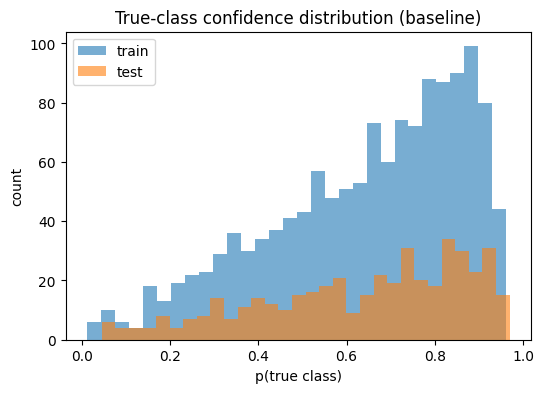

In [4]:
def true_class_confidence(model, X, y, batch=256):
    model.eval()
    confs = []
    entrs = []
    losses = []
    with torch.no_grad():
        for i in range(0, len(X), batch):
            xb, yb = X[i:i+batch], y[i:i+batch]
            logits = model(xb)
            prob = F.softmax(logits, dim=1)
            p_true = prob.gather(1, yb.view(-1,1)).view(-1)
            ent = (-prob * (prob + 1e-12).log()).sum(dim=1)
            loss = F.cross_entropy(logits, yb, reduction='none')
            confs.append(p_true.cpu().numpy())
            entrs.append(ent.cpu().numpy())
            losses.append(loss.cpu().numpy())
    return np.concatenate(confs), np.concatenate(entrs), np.concatenate(losses)

def membership_risk_proxy(model):
    c_tr, e_tr, l_tr = true_class_confidence(model, X_train_t, y_train_t)
    c_te, e_te, l_te = true_class_confidence(model, X_test_t,  y_test_t)

    gap_conf = float(c_tr.mean() - c_te.mean())
    gap_loss = float(l_te.mean() - l_tr.mean())
    gap_ent  = float(e_te.mean() - e_tr.mean())

    # AUC：区分 train vs test 的可分辨性（聚合评估）
    from sklearn.metrics import roc_auc_score
    labels = np.concatenate([np.ones_like(c_tr), np.zeros_like(c_te)])
    scores = np.concatenate([c_tr, c_te])  # 置信度越高越像 train
    auc = float(roc_auc_score(labels, scores))

    return {
        'train_conf_mean': float(c_tr.mean()),
        'test_conf_mean' : float(c_te.mean()),
        'gap_conf'       : gap_conf,
        'gap_loss'       : gap_loss,
        'gap_entropy'    : gap_ent,
        'auc_sep'        : auc,
        'train_conf'     : c_tr,
        'test_conf'      : c_te
    }

r_base = membership_risk_proxy(base)
print('Baseline risk proxy:')
for k in ['train_conf_mean','test_conf_mean','gap_conf','gap_loss','gap_entropy','auc_sep']:
    print(f'  {k:>15s}: {r_base[k]:.6f}')

plt.figure(figsize=(6,4))
plt.hist(r_base['train_conf'], bins=30, alpha=0.6, label='train')
plt.hist(r_base['test_conf'],  bins=30, alpha=0.6, label='test')
plt.title('True-class confidence distribution (baseline)')
plt.xlabel('p(true class)')
plt.ylabel('count')
plt.legend()
plt.show()


## 4. 属性重建：风险理解（不做重建实现）

属性重建/属性推断的典型路径：
- 攻击者拥有 **侧信息**（部分字段、用户群体分布、公开资料等）
- 模型或中间表征对某些敏感属性（如身份/地点/病史/设备特征）存在可分辨性
- 通过统计学习或关联推断，推测缺失/敏感属性

课堂要点：
- **中间表征越可分离，属性泄露风险越大**
- **输出越丰富（概率/向量/embedding），风险越高**

我们用一个安全的“表征可分辨性”指标来量化风险：
- 对一个“敏感属性”做模拟标签（例如：图像亮度是否高于阈值）
- 观察模型 embedding 对该属性的线性可分性（AUC）

> 这只是教学用 proxy，用来帮助学生理解“表征泄露”，不等价于真实世界的敏感属性重建。

Attribute separability AUC (proxy): 0.9878080158337457


C:\Users\wingl\PycharmProjects\adversarialmeow\.venv_test\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


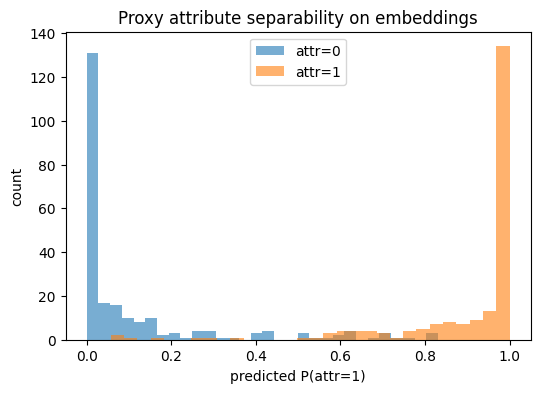

In [5]:
class MLPWithFeat(MLP):
    def feat(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return x

feat_model = MLPWithFeat().to(device)
feat_model.load_state_dict(base.state_dict())

# 构造一个“模拟敏感属性”：平均像素 > 阈值
thr = float(np.mean(X_train))
attr_train = (X_train.mean(axis=1) > thr).astype(np.int64)
attr_test  = (X_test.mean(axis=1)  > thr).astype(np.int64)

with torch.no_grad():
    Ztr = feat_model.feat(X_train_t).cpu().numpy()
    Zte = feat_model.feat(X_test_t ).cpu().numpy()

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

clf = LogisticRegression(max_iter=200)
clf.fit(Ztr, attr_train)
p = clf.predict_proba(Zte)[:,1]
auc_attr = float(roc_auc_score(attr_test, p))
print('Attribute separability AUC (proxy):', auc_attr)

plt.figure(figsize=(6,4))
plt.hist(p[attr_test==0], bins=30, alpha=0.6, label='attr=0')
plt.hist(p[attr_test==1], bins=30, alpha=0.6, label='attr=1')
plt.title('Proxy attribute separability on embeddings')
plt.xlabel('predicted P(attr=1)')
plt.ylabel('count')
plt.legend()
plt.show()


## 5. 差分隐私（DP）核心概念

### 5.1 定义直觉
一个算法满足 (ε, δ)-DP，意味着：
- 数据集中“是否包含某个个体”对输出分布的影响被严格上界限制
- ε 越小隐私越强（但通常精度/可用性会下降）

### 5.2 机制
- Laplace：用于纯 ε-DP（常见于计数/统计）
- Gaussian：用于 (ε, δ)-DP（常用于学习算法）

### 5.3 DP-SGD（机器学习常用）
- 对每个样本（或微批）梯度做 **范数裁剪**（clip）
- 对聚合梯度加入 **高斯噪声**（noise multiplier）

本节我们实现一个教学版 DP-SGD（小模型、小数据），用于观察：
- 精度下降程度
- 成员推理风险代理指标（gap_conf / auc_sep）是否降低


DP Epoch 01 | train=0.1024 | test=0.1000
DP Epoch 02 | train=0.1767 | test=0.2022
DP Epoch 04 | train=0.5835 | test=0.6111
DP Epoch 06 | train=0.7476 | test=0.7400
DP Epoch 08 | train=0.7795 | test=0.7511
DP acc: 0.7511111111111111

DP risk proxy:
  train_conf_mean: 0.121506
   test_conf_mean: 0.121761
         gap_conf: -0.000255
         gap_loss: -0.001863
      gap_entropy: -0.000094
          auc_sep: 0.494599


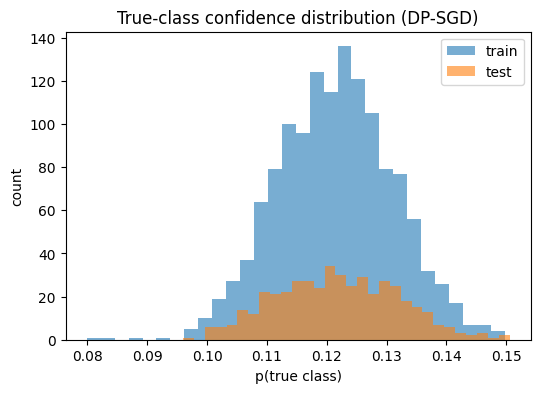

In [6]:
def train_dp_sgd(
    model,
    X,
    y,
    epochs=8,
    lr=1e-3,
    batch=128,
    max_grad_norm=1.0,
    noise_multiplier=0.8
):
    """教学版 DP-SGD：逐样本梯度裁剪 + 聚合后加噪。
    注意：这不是生产级实现（没有严格隐私会计/采样会计），只用于教学理解。
    """
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    n = len(X)

    for ep in range(1, epochs+1):
        model.train()
        perm = torch.randperm(n, device=X.device)
        for i0 in range(0, n, batch):
            idx = perm[i0:i0+batch]
            xb, yb = X[idx], y[idx]

            # 初始化聚合梯度
            agg_grads = [torch.zeros_like(p) for p in model.parameters()]

            # 逐样本计算梯度并裁剪（教学版，速度可接受）
            for j in range(len(xb)):
                opt.zero_grad(set_to_none=True)
                loss = F.cross_entropy(model(xb[j:j+1]), yb[j:j+1])
                loss.backward()

                # 计算总范数
                total_norm_sq = 0.0
                for p in model.parameters():
                    if p.grad is None:
                        continue
                    total_norm_sq += float(p.grad.detach().pow(2).sum().item())
                total_norm = math.sqrt(total_norm_sq) + 1e-12

                clip_coef = min(1.0, max_grad_norm / total_norm)
                for k, p in enumerate(model.parameters()):
                    if p.grad is None:
                        continue
                    agg_grads[k] += p.grad.detach() * clip_coef

            # 平均 + 加噪
            for k, p in enumerate(model.parameters()):
                g = agg_grads[k] / max(1, len(xb))
                noise_std = noise_multiplier * max_grad_norm / max(1, len(xb))
                g = g + torch.randn_like(g) * noise_std
                p.grad = g

            opt.step()

        if ep == 1 or ep == epochs or ep % 2 == 0:
            print(f'DP Epoch {ep:02d} | train={accuracy(model,X,y):.4f} | test={accuracy(model,X_test_t,y_test_t):.4f}')

    return model

import math

dp = MLP().to(device)
train_dp_sgd(dp, X_train_t, y_train_t, epochs=8, lr=1e-3, batch=128, max_grad_norm=1.0, noise_multiplier=0.9)
print('DP acc:', accuracy(dp, X_test_t, y_test_t))

r_dp = membership_risk_proxy(dp)
print('\nDP risk proxy:')
for k in ['train_conf_mean','test_conf_mean','gap_conf','gap_loss','gap_entropy','auc_sep']:
    print(f'  {k:>15s}: {r_dp[k]:.6f}')

plt.figure(figsize=(6,4))
plt.hist(r_dp['train_conf'], bins=30, alpha=0.6, label='train')
plt.hist(r_dp['test_conf'],  bins=30, alpha=0.6, label='test')
plt.title('True-class confidence distribution (DP-SGD)')
plt.xlabel('p(true class)')
plt.ylabel('count')
plt.legend()
plt.show()


## 6. 联邦差分机制（FedAvg + 聚合噪声：教学演示）

联邦学习的目标：数据不出端，模型更新汇聚。
隐私增强常见做法：
- 客户端更新裁剪（限制单个客户端贡献）
- 服务端聚合加噪（使单个客户端影响受控）

这里我们做一个简化版：
- 把训练集分成 K 个“客户端”
- 每轮每个客户端本地训练 1 个 epoch 得到 delta
- 服务器端做平均，并对平均 delta 加噪

> 同样：这是教学版流程，不包含严格隐私会计。

In [7]:
def get_params(model):
    return [p.detach().clone() for p in model.parameters()]

def set_params(model, params):
    with torch.no_grad():
        for p, q in zip(model.parameters(), params):
            p.copy_(q)

def add_params(a, b):
    return [x + y for x, y in zip(a, b)]

def sub_params(a, b):
    return [x - y for x, y in zip(a, b)]

def mul_params(a, s: float):
    return [x * s for x in a]

def clip_update(delta, max_norm=1.0):
    # 计算整体范数
    norm_sq = 0.0
    for d in delta:
        norm_sq += float(d.pow(2).sum().item())
    norm = math.sqrt(norm_sq) + 1e-12
    coef = min(1.0, max_norm / norm)
    return [d * coef for d in delta]

def local_train_one_epoch(model, X, y, lr=1e-3, batch=128, weight_decay=0.0):
    opt = torch.optim.SGD(model.parameters(), lr=lr, weight_decay=weight_decay)
    model.train()
    perm = torch.randperm(len(X), device=X.device)
    for i0 in range(0, len(X), batch):
        idx = perm[i0:i0+batch]
        xb, yb = X[idx], y[idx]
        loss = F.cross_entropy(model(xb), yb)
        opt.zero_grad(); loss.backward(); opt.step()

def fedavg_dp(
    X, y,
    K=5,
    rounds=10,
    lr=1e-2,
    client_batch=128,
    max_update_norm=1.0,
    noise_multiplier=0.6
):
    # 切分客户端
    n = len(X)
    idxs = torch.randperm(n, device=X.device)
    splits = torch.chunk(idxs, K)

    server = MLP().to(device)
    server_params = get_params(server)

    for r in range(1, rounds+1):
        deltas_sum = None
        for k in range(K):
            client = MLP().to(device)
            set_params(client, server_params)
            idk = splits[k]
            local_train_one_epoch(client, X[idk], y[idk], lr=lr, batch=client_batch)
            delta = sub_params(get_params(client), server_params)
            delta = clip_update(delta, max_norm=max_update_norm)
            deltas_sum = delta if deltas_sum is None else add_params(deltas_sum, delta)

        # 平均更新 + 加噪
        avg_delta = mul_params(deltas_sum, 1.0 / K)
        noisy_delta = []
        for d in avg_delta:
            noise_std = noise_multiplier * max_update_norm / K
            noisy_delta.append(d + torch.randn_like(d) * noise_std)

        server_params = add_params(server_params, noisy_delta)
        set_params(server, server_params)

        if r == 1 or r == rounds or r % 2 == 0:
            print(f'Round {r:02d} | test acc={accuracy(server, X_test_t, y_test_t):.4f}')

    return server

fed_dp_model = fedavg_dp(X_train_t, y_train_t, K=5, rounds=10, lr=1e-2, client_batch=128, max_update_norm=1.0, noise_multiplier=0.7)
print('Fed+DP acc:', accuracy(fed_dp_model, X_test_t, y_test_t))

r_fed = membership_risk_proxy(fed_dp_model)
print('\nFed+DP risk proxy:')
for k in ['gap_conf','gap_loss','gap_entropy','auc_sep']:
    print(f'  {k:>10s}: {r_fed[k]:.6f}')


Round 01 | test acc=0.1022
Round 02 | test acc=0.1689
Round 04 | test acc=0.1022
Round 06 | test acc=0.1422
Round 08 | test acc=0.0978
Round 10 | test acc=0.0911
Fed+DP acc: 0.09111111111111111

Fed+DP risk proxy:
    gap_conf: 0.022251
    gap_loss: 0.128000
  gap_entropy: -0.008019
     auc_sep: 0.504987


## 7. 输出最小化与“接口侧隐私”

当模型通过 API 对外服务时：
- 输出越丰富（概率向量、logits、embedding），隐私与知识泄露风险越高
- 输出最小化（label/top-k，概率量化、温度平滑、截断）能降低可分辨性

这里做一个小实验：
- 只用“真实类置信度”做风险代理
- 对概率做 rounding（模拟接口返回低精度）

注意：这不改变模型本身的训练隐私，但会降低输出侧可利用信息。

In [8]:
def confidence_with_rounding(model, X, y, decimals=None, batch=256):
    model.eval()
    confs = []
    with torch.no_grad():
        for i in range(0, len(X), batch):
            xb, yb = X[i:i+batch], y[i:i+batch]
            prob = F.softmax(model(xb), dim=1)
            if decimals is not None:
                prob = torch.round(prob * (10**decimals)) / (10**decimals)
            p_true = prob.gather(1, yb.view(-1,1)).view(-1)
            confs.append(p_true.cpu().numpy())
    return np.concatenate(confs)

from sklearn.metrics import roc_auc_score

def auc_sep_from_confs(c_tr, c_te):
    labels = np.concatenate([np.ones_like(c_tr), np.zeros_like(c_te)])
    scores = np.concatenate([c_tr, c_te])
    return float(roc_auc_score(labels, scores))

for decimals in [None, 3, 2, 1, 0]:
    c_tr = confidence_with_rounding(base, X_train_t, y_train_t, decimals=decimals)
    c_te = confidence_with_rounding(base, X_test_t,  y_test_t,  decimals=decimals)
    auc = auc_sep_from_confs(c_tr, c_te)
    gap = float(c_tr.mean() - c_te.mean())
    print(f'round={decimals} | gap_conf={gap:.6f} | auc_sep={auc:.6f}')


round=None | gap_conf=0.006941 | auc_sep=0.503415
round=3 | gap_conf=0.006936 | auc_sep=0.503408
round=2 | gap_conf=0.006850 | auc_sep=0.503328
round=1 | gap_conf=0.009503 | auc_sep=0.509582
round=0 | gap_conf=0.017951 | auc_sep=0.508976


## 8. 加密计算简介（不写代码，掌握适用边界）

### 8.1 多方安全计算（MPC）
- 适合：多方联合计算统计/训练，任何单方都不看到完整数据
- 代价：通信与协议开销大；深度模型训练成本更高

### 8.2 同态加密（HE）
- 适合：在密文上做推理/统计（典型是线性/低阶多项式算子）
- 代价：算子受限、计算非常慢；工程上常用于“局部敏感环节”

### 8.3 可信执行环境（TEE）
- 适合：把敏感计算放进硬件隔离区（如 SGX/SEV/TrustZone）
- 风险：侧信道、供应链、可信根依赖；需要配合审计与密钥管理

结论：
- DP 解决“统计泄露”与“个体影响可界定”；
- 加密计算解决“谁能看到数据/中间结果”；
- 工程上通常组合使用：联邦 + DP + 访问控制/审计 + 必要时 TEE/MPC/HE。

## 9. 本节练习
1) 训练三种模型：
- 标准训练（baseline）
- DP-SGD（调不同 noise_multiplier）
- 联邦+聚合噪声（调不同 noise_multiplier）

2) 对比三类指标：
- test accuracy
- gap_conf / auc_sep（成员推理风险代理）
- embedding 的 proxy 属性可分辨性 AUC（属性泄露 proxy）

3) 讨论：
- 为什么隐私增强往往牺牲精度？
- 为什么“输出最小化/量化”能降低可利用信息？
- 工程上你会如何选择：DP、联邦、TEE、MPC/HE 的组合？